<a href="https://colab.research.google.com/github/starsyntaxx/Olist-delivery-prediction/blob/main/notebooks/exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Environment Setup & Data Extraction
import os
import zipfile
from google.colab import files

# Upload raw data archive
if not os.path.exists("archive (1).zip"):
    print("Please upload your 'archive (1).zip' file:")
    uploaded = files.upload()

# Extract dataset to target directory
if os.path.exists("archive (1).zip") and not os.path.exists("data"):
    with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
        zip_ref.extractall("data")
    print("Data extracted successfully to /data folder.")

print("Available files:", os.listdir("data"))

Please upload your 'archive (1).zip' file:


Saving archive (1).zip to archive (1).zip
Data extracted successfully to /data folder.
Available files: ['olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'product_category_name_translation.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_customers_dataset.csv', 'olist_products_dataset.csv']


In [2]:
# 2. Core Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Quick view of the whole daataset.

In [3]:
# 3. Global Schema Assessment
datasets_paths = {
    "orders": "data/olist_orders_dataset.csv",
    "customers": "data/olist_customers_dataset.csv",
    "geolocation": "data/olist_geolocation_dataset.csv",
    "order_reviews": "data/olist_order_reviews_dataset.csv",
    "order_items": "data/olist_order_items_dataset.csv",
    "order_payments": "data/olist_order_payments_dataset.csv",
    "sellers": "data/olist_sellers_dataset.csv",
    "products": "data/olist_products_dataset.csv"
}

datasets = {name: pd.read_csv(path) for name, path in datasets_paths.items()}

# Generate schema structural overview matrix
max_cols = max(len(df.columns) for df in datasets.values())
schema_data = {}
for name, df in datasets.items():
    cols = list(df.columns)
    cols += [None] * (max_cols - len(cols))
    schema_data[name] = cols

schema_table = pd.DataFrame.from_dict(schema_data, orient='index')
schema_table.columns = [f"Column_{i+1}" for i in range(max_cols)]
schema_table

,Column_1,Column_2,Column_3,Column_4,Column_5,Column_6,Column_7,Column_8,Column_9
orders,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,None
customers,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,None,None,None,None
geolocation,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,None,None,None,None
order_reviews,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,None,None
order_items,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,None,None
order_payments,order_id,payment_sequential,payment_type,payment_installments,payment_value,None,None,None,None
sellers,seller_id,seller_zip_code_prefix,seller_city,seller_state,None,None,None,None,None
products,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [4]:
os.listdir("data")

['olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'product_category_name_translation.csv',
 'olist_sellers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_products_dataset.csv']

In [5]:
#Initialize all dataset

orders = pd.read_csv("data/olist_orders_dataset.csv")
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
order_payments = pd.read_csv("data/olist_order_payments_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
order_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")

**View of Central Table: Orders Dataset**

In [6]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Relationship Analysis Between Central Table and other Data Table**

In [7]:
# 4. Relational Integrity Validation Checks

print("1. Orders map cleanly to Items (All IDs account for):")
print(datasets['orders']['order_id'].isin(datasets['order_items']['order_id']).all())

print("\n2. Items missing from target reference counts:")
unlinked_orders_count = datasets['orders'][~datasets['orders']['order_id'].isin(datasets['order_items']['order_id'])].shape[0]
print(f"Total unlinked orders: {unlinked_orders_count}")

print("\n3. Functional breakdown of unlinked order statuses:")
print(datasets['orders'][~datasets['orders']['order_id'].isin(datasets['order_items']['order_id'])]['order_status'].value_counts())

print("\n4. seller-buyer status:")
print(datasets['order_items']['seller_id'].isin(datasets['sellers']['seller_id']).all())

print("\n5. Order_items & Product Table Correlation")
print(datasets['products']['product_id'].isin(datasets['order_items']['product_id']).all())

print("\n5. Orders & Customer Table Correlation")
print(datasets['orders']['customer_id'].isin(datasets['customers']['customer_id']).all())

print("\n7. Zip Code Mapping Failures:")
cust_geo_missing = (~datasets['customers']['customer_zip_code_prefix'].isin(datasets['geolocation']['geolocation_zip_code_prefix'])).sum()
seller_geo_missing = (~datasets['sellers']['seller_zip_code_prefix'].isin(datasets['geolocation']['geolocation_zip_code_prefix'])).sum()
print(f"Customers unmapped to Geolocation zip prefix: {cust_geo_missing}")
print(f"Sellers unmapped to Geolocation zip prefix: {seller_geo_missing}")

1. Orders map cleanly to Items (All IDs account for):
False

2. Items missing from target reference counts:
Total unlinked orders: 775

3. Functional breakdown of unlinked order statuses:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

4. seller-buyer status:
True

5. Order_items & Product Table Correlation
True

5. Orders & Customer Table Correlation
True

7. Zip Code Mapping Failures:
Customers unmapped to Geolocation zip prefix: 278
Sellers unmapped to Geolocation zip prefix: 7


1. Orders(1) - Order_items(many)

In [ ]:
order_items.groupby('order_id').size().value_counts()

,count
1,88863
2,7516
3,1322
4,505
5,204
6,198
7,22
8,8
10,8
12,5


In [8]:
# 5. Production Data Pipeline & Cleaning Engine

def build_clean_order_cohort(datasets):
    orders = datasets['orders'].copy()
    order_items = datasets['order_items'].copy()

    # Filter to orders containing verified items
    valid_item_ids = order_items['order_id'].unique()
    clean_df = orders[orders['order_id'].isin(valid_item_ids)].copy()

    # Retain strictly completed delivery transactions
    clean_df = clean_df[clean_df['order_status'] == 'delivered']

    # Drop rows missing crucial process timestamps
    clean_df.dropna(subset=[
        'order_delivered_customer_date',
        'order_approved_at',
        'order_delivered_carrier_date'
    ], inplace=True)

    return clean_df

orders_clean = build_clean_order_cohort(datasets)
print(f"Stabilized absolute volume: {orders_clean.shape[0]} tracking samples.")
print("Null verification check:\n", orders_clean.isnull().sum())

Stabilized absolute volume: 96455 tracking samples.
Null verification check:
 order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


In [9]:
orders_clean.describe()

#central table is stabilized already

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,96455,96455,96455,96455,96455,96455,96455,96455
unique,96455,96455,1,95933,88266,80094,95643,445
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-06-01 13:39:44,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96455,3,9,47,3,507


*Dataset Filtering: Defining Valid Order Cohort*

*At this stage of the analysis, I filtered the orders dataset to retain only those records that have corresponding entries in the order_items table. This step was necessary to ensure that the dataset represents valid and complete transactional orders that entered the fulfillment pipeline.*

*During exploration, it was discovered that a subset of orders did not have associated items. Further investigation showed that these orders were predominantly in the canceled, unavailable, or early-stage statuses such as created. Since these orders never progressed to item-level processing, they do not represent complete transactions and therefore cannot contribute meaningful information for delivery time prediction.*

*By applying an inner filter using order_id, I restricted the dataset to only orders that exist in both orders and order_items, effectively defining the valid modeling population.*


Define (?) - (?) Relationship between Relational Dataset

In [10]:
print("1. orders - products: ")
print(orders.groupby('customer_id').size().value_counts())
print("\n")

print(products.groupby('product_id').size().value_counts())

print(order_items.groupby('product_id').size().value_counts().sort_index())

print("4. order-items - sellers: ")
print(order_items.groupby('seller_id').size().value_counts()) #Distribution of sellers activity

1. orders - products: 
1    99441
Name: count, dtype: int64


1    32951
Name: count, dtype: int64
1      18117
2       5817
3       2651
4       1534
5        994
       ...  
388        1
392        1
484        1
488        1
527        1
Name: count, Length: 138, dtype: int64
4. order-items - sellers: 
1      509
2      328
3      212
4      152
5      142
      ... 
211      1
631      1
536      1
183      1
306      1
Name: count, Length: 257, dtype: int64


In [ ]:
order_items['seller_id'].value_counts().head()

,count
seller_id,
6560211a19b47992c3666cc44a7e94c0,2033
4a3ca9315b744ce9f8e9374361493884,1987
1f50f920176fa81dab994f9023523100,1931
cc419e0650a3c5ba77189a1882b7556a,1775
da8622b14eb17ae2831f4ac5b9dab84a,1551


Uncertainity Stage: Eploratory Data Analysis Begins

In [11]:
orders.describe()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [12]:
# Cast temporal elements to precise datetime format
datetime_cols = ['order_purchase_timestamp',
                 'order_delivered_customer_date',
                 'order_estimated_delivery_date',
                 'order_approved_at',
                 'order_delivered_carrier_date']
for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col])

 **Observation; Out of 99441 unque order, only 459 order etimated delivery date is spread out, majority of order-rows has the exact same delivery date, despite differings in order_approved_then**

 **Hypothesis: A simple algorithm was estimated to predict estimated_delivery _date**

In [13]:
orders.head()
orders.shape
orders.info()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [14]:
# Missing values exist

orders['not_delivered'] = orders['order_delivered_customer_date'].isnull()
orders.groupby('order_status')['not_delivered'].value_counts()

order_status  not_delivered
approved      True                 2
canceled      True               619
              False                6
created       True                 5
delivered     False            96470
              True                 8
invoiced      True               314
processing    True               301
shipped       True              1107
unavailable   True               609
Name: count, dtype: int64

In [15]:
orders['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [16]:
orders[orders['order_status'] == 'shipped']['order_delivered_carrier_date'].isnull().sum()

np.int64(0)

**Conclusion: Missing values observed in delivery timestamp columns is analyzed and found to be primarily associated with the business process state of orders during data capture rather than database inconsistencies or system failures. Orders with statuses such as shipped, processing, or canceled naturally lacked certain downstream delivery timestamps because those events had not yet occurred at the time of recording.**

In [17]:
#Now unto data cleaning
df = orders[orders['order_status'] == 'delivered'].copy()
df['order_delivered_customer_date'].isnull().sum()

#observation: 8 customers with delivered tag are missing delivery dates


np.int64(8)

In [18]:
# Check: Average value of inaccurate predicted estimated_delivery_date occurences.
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

df['delivery_delay_days'].head()

,delivery_delay_days
0,-8.0
1,-6.0
2,-18.0
3,-13.0
4,-10.0


**On average, orders are delivered approximately 12 days earlier than the estimated delivery date, indicating that the estimation system is conservative. However, there is significant variability in delivery performance, with some extreme early and late deliveries, suggesting inconsistency in logistics or estimation accuracy.**

In [19]:
df['delivery_delay_days'].describe()

,delivery_delay_days
count,96470.000000
mean,-11.875889
std,10.182105
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


In [20]:
df['delivery_delay_days'].value_counts()

,count
delivery_delay_days,
-14.0,7126
-13.0,5963
-15.0,5345
-7.0,4837
-8.0,4828
...,...
-63.0,1
72.0,1
94.0,1


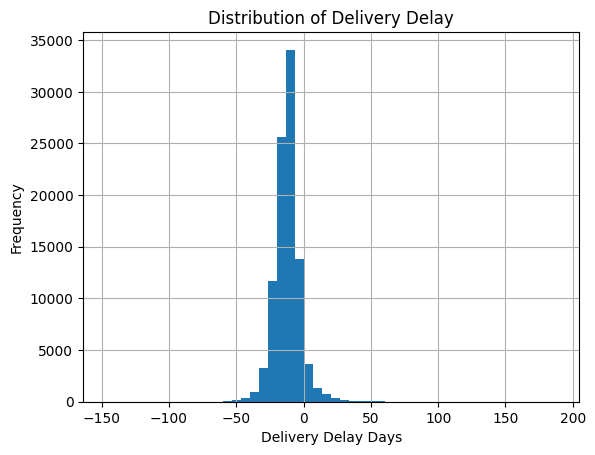

In [37]:
# Plot distribution Graph
df['delivery_delay_days'].hist(bins=50)

plt.xlabel("Delivery Delay Days")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Delay")

plt.show()

In [21]:
#Was there any order delivery date that was predicted accurately to detect the accuracy of the delivery date?
df['delivery_matched_dates'] = (
    df['order_delivered_customer_date'].dt.date ==
    df['order_estimated_delivery_date'].dt.date
)

df['delivery_matched_dates'].describe()


,delivery_matched_dates
count,96478
unique,2
top,False
freq,95186


In [22]:
matched_orders = df[
    df['order_delivered_customer_date'].dt.date ==
    df['order_estimated_delivery_date'].dt.date
]

matched_orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
count,1292,1292,1292,1292,1292,1292.0
mean,2018-02-22 02:03:04.214396160,2018-02-22 14:37:26.962848256,2018-02-26 18:43:00.921052672,2018-03-13 07:23:39.443498496,2018-03-12 14:37:09.102167296,0.0
min,2016-10-10 15:01:27,2016-10-10 15:44:46,2016-11-14 07:41:23,2016-12-14 08:03:48,2016-12-14 00:00:00,0.0
25%,2017-11-25 15:09:24.500000,2017-11-26 03:24:11.750000128,2017-11-29 23:40:03.500000,2017-12-19 15:58:24.500000,2017-12-19 00:00:00,0.0
50%,2018-03-07 09:55:52,2018-03-07 11:50:33.500000,2018-03-12 16:28:24,2018-03-28 07:17:47,2018-03-28 00:00:00,0.0
75%,2018-07-16 12:12:06.500000,2018-07-16 12:24:07.500000,2018-07-23 15:14:00,2018-08-01 06:08:30.750000128,2018-08-01 06:00:00,0.0
max,2018-08-28 22:51:54,2018-08-28 23:05:10,2018-08-29 14:43:00,2018-08-31 02:21:48,2018-08-31 00:00:00,0.0
std,NaN,NaN,NaN,NaN,NaN,0.0


*Out of 9912 orders and their delivery dates, 1291 orders were accurate as the estimated delivery time equaled the actual delivery date, 95186 were not accurate as the actual delivery dates deviated from the estimated delivery date*

MODEL USAGE
1. Filter out orders without a customer_actual_delivery_time as it is not needed for the model

**Data Frames for Modelling**
Important Filter == Delivered
1. Order Purchase timestamp
2. Order_approved_at
3. Order_estimated_delivery_date
4. Order_status
5. Order_delivered-customer_date


**Certainity Stage: Build a model to predict with a higher accuracy the estimated delivery date**

----------------------------------------------------------------Another Dataset--------------------------------------------------------

**Customers Dataset**

In [ ]:
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Temporal features for Feature Engineering
1. customer_zip_code-prefix
2. customer_city
4. vustomer_date

In [ ]:
customers.info()
# relationship question: Number of customers equals order, so the customer correlates with a one-one relationship with the order dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   customer_id               99441 non-null  object  
 1   customer_unique_id        99441 non-null  object  
 2   customer_zip_code_prefix  99441 non-null  category
 3   customer_city             99441 non-null  object  
 4   customer_state            99441 non-null  object  
dtypes: category(1), object(4)
memory usage: 3.8+ MB


In [ ]:
customers['customer_unique_id'].value_counts()
#Inference; A number of customers bought products at different times, more than once.

,count
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,17
3e43e6105506432c953e165fb2acf44c,9
ca77025e7201e3b30c44b472ff346268,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7
6469f99c1f9dfae7733b25662e7f1782,7
...,...
4f83c83b7ff5b544a8c75dcb8ad66e2e,1
3fe413dde400746c53c5d0d38b266ca2,1
289e1d1ce11a14bb169775d58ad2f1c2,1


Dataset
1. Customer zip code prefix

Advanced: Feature Engineeering behaviour
1. Customers that bought a number of products at once did it affect their delivery time. Order Id from order dataset and Order Id from Order_Product dataset

In [ ]:
# Did all of the customers here engage in orders?
# Observe the relationship between an order estimated time and (i)the review and (ii)number of times it was bought?


----------------------------------------------------------------Another Dataset--------------------------------------------------------

**Geolocation Dataset**;

In [ ]:
geolocation.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Temporal features for Feature Engineering
1. geolocation_zip_code_prefix
2. geolocation_lat
3. geolocation_lng

In [ ]:
geolocation.isnull().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [ ]:
geolocation.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [ ]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


Dataset:

customer/seller table------> zip_code_prefix-----> geolocation table-latitude-----> longitude

**Order Review Dataset**

In [ ]:

order_reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insightful Questions**

*Does late delivery correlate with low scores?*

*Which sellers get worst reviews?*

*Does delivery time affect satisfaction?*

*The order-review dataset is excluded from model training as it represents post-event information. Including it would introduce target leakage and potentially lead to overfitting, as review scores are influenced by delivery outcomes rather than available at prediction time.*

**Order Items Dataset**

In [ ]:

order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Temporal Features for Feature Engineering
1. price
2. freight value

orders['order_id'] -> order_items['order_id'] == One-to-many relationship
Orders' counts products, while order_items counts products in orders

Dataset: Filter by order id to have a one-one relationship == 'delivered'
1. Freight_value.
2. Shipping_limit_date.

Advanced: Feature Engineering
1. Does the number of products a customer buy affect delivery date?

**Order Payments Dataset**

In [ ]:

order_payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Sellers dataset**

In [ ]:

sellers.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Temporal Features for Feature Engineering
1. seller-zip-code-prefix
2. seller state

Seller-customer: One-to-many relationship.

In [ ]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.893848,-47.061337
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,13844.0,-22.383437,-46.947927
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,20031.0,-22.909572,-43.177703
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,4195.0,-23.657242,-46.612831
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,12914.0,-22.964803,-46.534419


In [ ]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


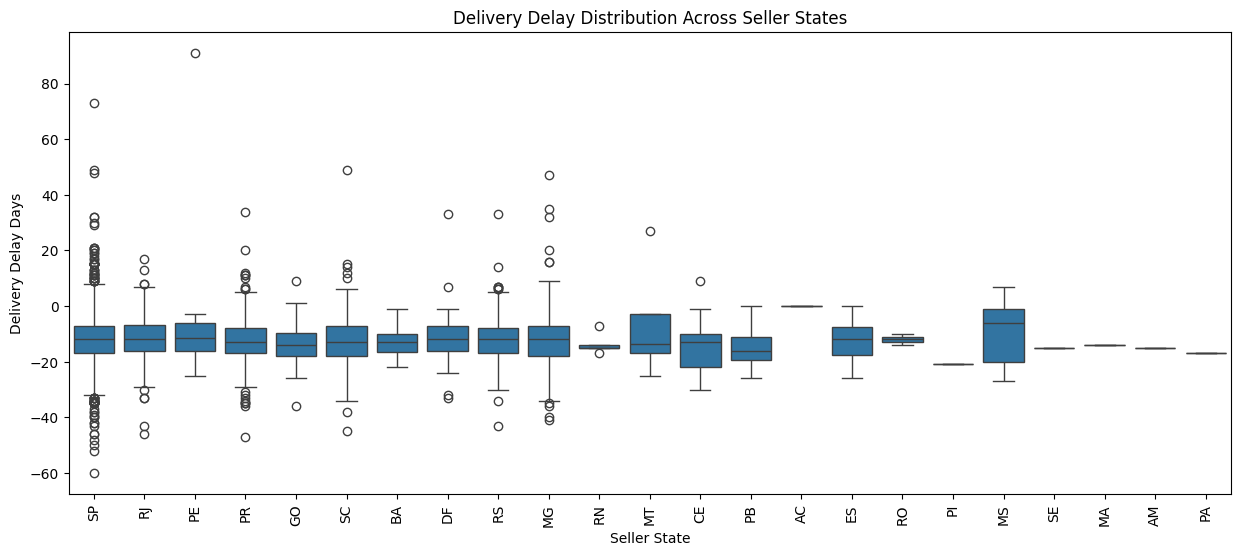

In [ ]:
plt.figure(figsize=(15,6))

sns.boxplot(
    x=sellers['seller_state'],
    y=df['delivery_delay_days'],
    data=df
)

plt.title('Delivery Delay Distribution Across Seller States')

plt.xlabel('Seller State')
plt.ylabel('Delivery Delay Days')

plt.xticks(rotation=90)
plt.show()

*Delivery delay distributions across seller states show that most orders are delivered earlier than the estimated delivery date, suggesting that the platform’s estimation system is generally conservative. While some regional variation exists, seller state alone does not appear to strongly differentiate delivery performance.*

Dataset:
1. Seller_zip_code Prefix: Distance between seller and buyer (new table).
2. Seller_state

Advanced: Feature Engineering.
1. Seller_state importance against bias
2. Seller_id

**Product Dataset**

In [ ]:

products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Temopral Features for Feature Engineering
1. product_category_name
2. product_weight_g
3. product_length_cm
4. product_height_cm
5. product_width_cm

In [ ]:
order_items_clean.head()

,product_id,seller_id,price,freight_value
order_id,,,,
00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


*Interacting with the product dataset.*

In [ ]:
products['product_category_name'].value_counts()

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
fashion_roupa_infanto_juvenil,5
casa_conforto_2,5
pc_gamer,3


In [ ]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
missing_products = products[products['product_category_name'].isnull()]
missing_products_ids = missing_products['product_id']
matched_orders = order_items[order_items['product_id'].isin(missing_products_ids)]

In [ ]:
matched_orders['product_id'].nunique()

610

In [ ]:
missing_products_ids.nunique()

610

*All products with missing product_category_name were still present in actual order transactions, meaning they were successfully sold despite lacking category labels. This indicates that the missing category values are a metadata issue rather than a data availability problem.*

DataSet
1. Product weight
2. Volume = length × height × width
3. Density = weight / volume

**PREPARING DATA FOR MODELLING**

Big Table Merge
order_purchase_timestamp,
order_approved_at,
order_delivered_carrier_date,
order_delivered_customer_date,
delivery_delay_days,
total_fulfillment_time,
processing_time,
shipping_time,
carrier_delay

*After merging and having a final dataset, feature engineering begins.*

In [ ]:
order_features = order_items_clone.groupby('order_id').agg({

    # ─────────────────────
    # ORDER STRUCTURE
    # ─────────────────────
    'order_item_id': 'count',          # number of items in order
    'product_id': 'nunique',           # product diversity
    'seller_id': 'nunique',            # seller complexity

    # ─────────────────────
    # PRICE FEATURES
    # ─────────────────────
    'price': ['sum', 'mean', 'max'],
    'freight_value': ['sum', 'mean'],

    # ─────────────────────
    # PRODUCT COMPLEXITY
    # ─────────────────────
    'product_name_lenght': 'mean',
    'product_description_lenght': 'mean',
    'product_photos_qty': 'mean',

    'product_weight_g': 'sum',

    'product_length_cm': 'mean',
    'product_height_cm': 'mean',
    'product_width_cm': 'mean',

    # ─────────────────────
    # GEO (TEMPORARY - NOT FINAL FEATURE YET)
    # ─────────────────────
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
})

order_items_clone = order_items_clone.groupby('order_id').agg({
    'product_id': 'nunique',
    'seller_id': 'nunique',
    'price': 'sum',
    'freight_value': 'sum',
    'product_category_name': 'nunique',
    'product_weight_g': 'sum',
    'product_length_cm': 'mean',
    'product_height_cm': 'mean',
    'product_width_cm': 'mean'
})


order_items_clone = order_items_clean.copy()
order_items_clean = order_items[
    order_items['order_id'].isin(orders_clean['order_id'])
]
products_clone = products.copy()
sellers_clone = sellers.copy()
order_items_clone = order_items_clone.merge(
    products_clone,
    on="product_id",
    how="left"
).merge(
    sellers_clone,
    on="seller_id",
    how="left"
)

products['product_id'].isin(order_items['product_id']).all()

order_items_clean = order_items_clean.groupby('order_id').agg({
    'product_id': 'nunique',
    'seller_id': 'nunique',
    'price': 'sum',
    'freight_value': 'sum',
})

customers_clone = customers.copy()

orders_clean_clone = orders_clean.merge(
    customers_clone,
    on="customer_id",
    how="left"
)

order_features.columns = [
    '_'.join(col).strip() if isinstance(col, tuple) else col
    for col in order_features.columns
]

final_df = orders_clean_clone.merge(
    order_features,
    on="order_id",
    how="left"
)

TABLE MERGING & AGGREGATION WORKFLOW

In [23]:
#Clean Geolocation Lookup
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [27]:
geolocation.groupby('geolocation_zip_code_prefix').size()

,0
geolocation_zip_code_prefix,
1001,26
1002,13
1003,17
1004,22
1005,25
...,...
99960,5
99965,6
99970,21


In [28]:
geo_lookup = (
    geolocation
    .groupby("geolocation_zip_code_prefix")
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean"
    })
    .reset_index()
)

In [30]:
geo_lookup.groupby('geolocation_zip_code_prefix').size()

,0
geolocation_zip_code_prefix,
1001,1
1002,1
1003,1
1004,1
1005,1
...,...
99960,1
99965,1
99970,1


**#Merge Customers dataset and geo_lookup**

In [53]:

customer_features = customers.merge(
    geo_lookup,
    how="left",
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix"
)

In [54]:
customer_features.drop(
    columns=["geolocation_zip_code_prefix"],
    inplace=True
)

In [55]:
customer_features.rename(
    columns={
        "geolocation_lat": "customer_lat",
        "geolocation_lng": "customer_lng"
    },
    inplace=True
)

In [36]:
customer_features.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.498489,-47.396929
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.727992,-46.542848
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531642,-46.656289
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.499702,-46.185233
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975100,-47.142925


In [37]:
customer_features.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0
customer_lat,278
customer_lng,278


In [59]:
#Feature engineer missing values
customer_features["customer_geo_missing"] = (
    customer_features["customer_lat"].isna().astype(int)
)

In [42]:

state_means = customer_features.groupby("customer_state")[["customer_lat","customer_lng"]].transform("mean")

customer_features["state_lat"] = state_means["customer_lat"]
customer_features["state_lng"] = state_means["customer_lng"]

customer_features["lat_diff_state"] = customer_features["customer_lat"] - customer_features["state_lat"]
customer_features["lng_diff_state"] = customer_features["customer_lng"] - customer_features["state_lng"]

In [60]:
customer_features.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_geo_missing
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.498489,-47.396929,0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.727992,-46.542848,0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531642,-46.656289,0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.499702,-46.185233,0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975100,-47.142925,0


**Merge sellers + geo-lookup**

In [57]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [45]:
seller_features = sellers.merge(
    geo_lookup,
    how="left",
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix"
)

In [46]:
#drop redundant feature
seller_features.drop(
    columns=["geolocation_zip_code_prefix"],
    inplace=True
)

In [48]:
#Rename seller coordinates
seller_features.rename(
    columns={
        "geolocation_lat": "seller_lat",
        "geolocation_lng": "seller_lng"
    },
    inplace=True
)

In [50]:
seller_features.isnull().sum()


,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0
seller_lat,7
seller_lng,7


In [62]:
seller_features.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,seller_geo_missing
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,-22.893848,-47.061337,0
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,-22.383437,-46.947927,0
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,-22.909572,-43.177703,0
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,-23.657242,-46.612831,0
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,-22.964803,-46.534419,0


In [61]:
#Feature engineer missing values
seller_features["seller_geo_missing"] = (
    seller_features["seller_lat"].isna().astype(int)
)

**Enrich Order-Items Table**

In [63]:
order_items_enriched = order_items.copy()

In [66]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [64]:
# Merge seller features
order_items_enriched = order_items_enriched.merge(
    seller_features,
    how="left",
    on="seller_id"
)

In [67]:
# Merge Product features
order_items_enriched = order_items_enriched.merge(
    products,
    how="left",
    on="product_id"
)

In [68]:
order_items_enriched.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,...,seller_lng,seller_geo_missing,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP,...,-44.127492,0,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP,...,-46.518565,0,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG,...,-46.171124,0,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP,...,-47.387359,0,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR,...,-53.135873,0,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [78]:
order_items_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   order_id                    112650 non-null  object 
 1   order_item_id               112650 non-null  int64  
 2   product_id                  112650 non-null  object 
 3   seller_id                   112650 non-null  object 
 4   shipping_limit_date         112650 non-null  object 
 5   price                       112650 non-null  float64
 6   freight_value               112650 non-null  float64
 7   seller_zip_code_prefix      112650 non-null  int64  
 8   seller_city                 112650 non-null  object 
 9   seller_state                112650 non-null  object 
 10  seller_lat                  112397 non-null  float64
 11  seller_lng                  112397 non-null  float64
 12  seller_geo_missing          112650 non-null  int64  
 13  product_catego

In [72]:
order_items_enriched['order_id'].value_counts().head()
#There is a need to aggregate

,count
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20
9ef13efd6949e4573a18964dd1bbe7f5,15
428a2f660dc84138d969ccd69a0ab6d5,15


In [76]:
order_items_enriched.shape

(112650, 21)

In [77]:
order_items_enriched["order_id"].nunique()

98666

**Calculate seller-customer distance**

In [79]:
order_items_enriched = order_items_enriched.merge(
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

In [80]:
order_items_enriched = order_items_enriched.merge(
    customer_features,
    on="customer_id",
    how="left"
)

In [81]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [82]:
order_items_enriched["delivery_distance_km"] = haversine(
    order_items_enriched["customer_lat"],
    order_items_enriched["customer_lng"],
    order_items_enriched["seller_lat"],
    order_items_enriched["seller_lng"]
)

In [83]:
order_items_enriched["lat_diff"] = (
    order_items_enriched["seller_lat"] - order_items_enriched["customer_lat"]
)

order_items_enriched["lng_diff"] = (
    order_items_enriched["seller_lng"] - order_items_enriched["customer_lng"]
)

In [85]:
order_items_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   order_id                    112650 non-null  object 
 1   order_item_id               112650 non-null  int64  
 2   product_id                  112650 non-null  object 
 3   seller_id                   112650 non-null  object 
 4   shipping_limit_date         112650 non-null  object 
 5   price                       112650 non-null  float64
 6   freight_value               112650 non-null  float64
 7   seller_zip_code_prefix      112650 non-null  int64  
 8   seller_city                 112650 non-null  object 
 9   seller_state                112650 non-null  object 
 10  seller_lat                  112397 non-null  float64
 11  seller_lng                  112397 non-null  float64
 12  seller_geo_missing          112650 non-null  int64  
 13  product_catego